In [1]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PRATIKSHA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\PRATIKSHA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [1]:
import pandas as pd
import string
import nltk

# Download stopwords (important)
nltk.download('stopwords')

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix


#  LOAD DATASET

messages = pd.read_csv(r"C:\Users\OMKAR\Desktop\spam.csv", encoding='latin-1')

# Keep only required columns
messages = messages[['v1', 'v2']]
messages.columns = ['class', 'text']


#  TEXT PROCESSING

def process_text(text):
    # Remove punctuation
    nopunc = [char for char in text if char not in string.punctuation]
    nopunc = ''.join(nopunc)
    
    # Remove stopwords
    return [word for word in nopunc.split() if word.lower() not in stopwords.words('english')]


# SPLIT DATA

msg_train, msg_test, class_train, class_test = train_test_split(
    messages['text'], messages['class'], test_size=0.2
)


# PIPELINE

pipeline = Pipeline([
    ('bow', CountVectorizer(analyzer=process_text)),
    ('tfidf', TfidfTransformer()),
    ('classifier', MultinomialNB())
])

# Train model
pipeline.fit(msg_train, class_train)

# Predict
predictions = pipeline.predict(msg_test)


#  RESULTS

print("Confusion Matrix:\n")
print(confusion_matrix(class_test, predictions))

print("\nClassification Report:\n")
print(classification_report(class_test, predictions))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\OMKAR\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Confusion Matrix:

[[971   0]
 [ 33 111]]

Classification Report:

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       971
        spam       1.00      0.77      0.87       144

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



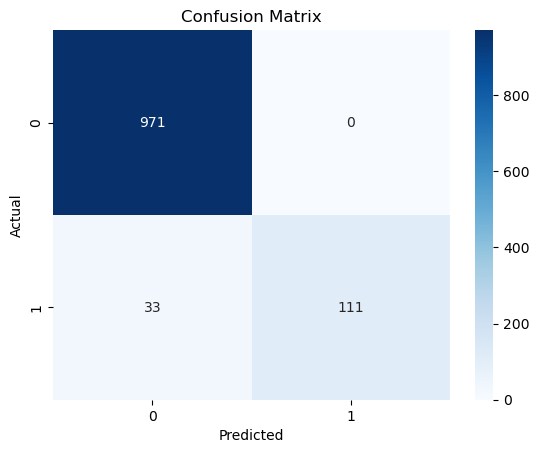

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(class_test, predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

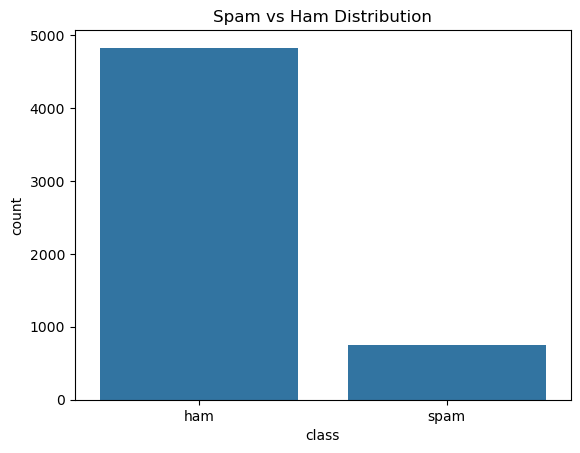

In [3]:
sns.countplot(x='class', data=messages)
plt.title('Spam vs Ham Distribution')
plt.show()

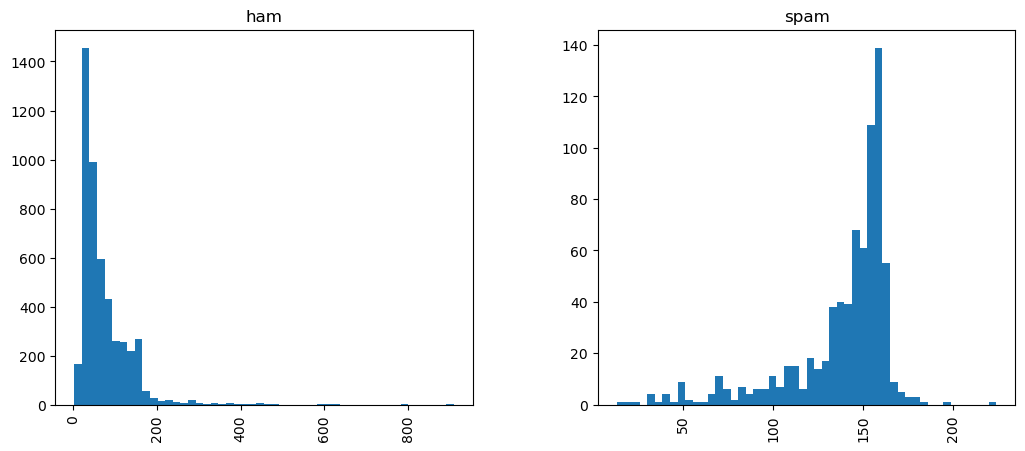

In [4]:
messages['length'] = messages['text'].apply(len)

messages.hist(column='length', by='class', bins=50, figsize=(12,5))
plt.show()